# DeBERTa-v3-base PCL Detection — Subtask 1 (Binary Classification)

Fine-tunes `microsoft/deberta-v3-base` on the **Don't Patronize Me** dataset for binary classification of Patronising and Condescending Language (PCL).

**Architecture:** `[CLS]` token → Dropout(0.4) → Linear(1024→2) → Softmax  
**Preprocessing:** expand contractions · strip HTML · remove non-alpha characters  
**Training:** AdamW (lr=1e-5, wd=0.01) · cosine schedule + 10% linear warmup · batch 16 · early stopping (patience 50 batches)

In [1]:
# ============================================================
# Cell 1: Install dependencies (run once, then restart kernel)
# ============================================================
!pip install contractions huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00


In [2]:
def load_task1(train_path):
		"""
		Load task 1 training set and convert the tags into binary labels. 
		Paragraphs with original labels of 0 or 1 are considered to be negative examples of PCL and will have the label 0 = negative.
		Paragraphs with original labels of 2, 3 or 4 are considered to be positive examples of PCL and will have the label 1 = positive.
		It returns a pandas dataframe with paragraphs and labels.
		"""
		rows=[]
		with open(train_path) as f:
			for line in f.readlines()[4:]:
				par_id=line.strip().split('\t')[0]
				art_id = line.strip().split('\t')[1]
				keyword=line.strip().split('\t')[2]
				country=line.strip().split('\t')[3]
				t=line.strip().split('\t')[4]#.lower()
				l=line.strip().split('\t')[-1]
				if l=='0' or l=='1':
					lbin=0
				else:
					lbin=1
				rows.append(
					{'par_id':par_id,
					'art_id':art_id,
					'keyword':keyword,
					'country':country,
					'text':t, 
					'label':lbin, 
					'orig_label':l
					}
					)
		df=pd.DataFrame(rows, columns=['par_id', 'art_id', 'keyword', 'country', 'text', 'label', 'orig_label']) 
		return df

In [3]:
# ============================================================
# Cell 2: Imports and reproducibility seeds
# ============================================================
import os
import re
import random
import logging
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import contractions

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)


# ---------- Fix all seeds ----------
SEED = 42

def set_seed(seed: int = 42) -> None:
    """Seed Python, NumPy, PyTorch (CPU + CUDA) for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [4]:
# ============================================================
# Cell 3: Hyper-parameters and paths
# ============================================================

# Model
MODEL_NAME     = 'microsoft/deberta-v3-base'
MAX_LENGTH     = 256
DROPOUT_RATE   = 0.4
NUM_LABELS     = 2

# Training
BATCH_SIZE     = 16
NUM_EPOCHS     = 10
LEARNING_RATE  = 1e-5
WEIGHT_DECAY   = 0.01
ADAMW_EPS      = 1e-6
WARMUP_RATIO   = 0.10       # first 10% of total steps used for linear warmup
MAX_GRAD_NORM  = 1.0

# Early stopping
# Patience is expressed in evaluation events: after PATIENCE consecutive
# non-improving evals (counting starts after warmup) the run is stopped.
EVAL_EVERY     = 20          # evaluate dev set every N training batches
PATIENCE       = 10        # eval events without improvement (post-warmup) → stop

# Logging and checkpointing
LOG_EVERY      = 50         # log training loss every N steps
CHECKPOINT_DIR = 'checkpoints/deberta_v3_pcl'
LOG_DIR        = 'logs'
BEST_CKPT_PATH = os.path.join(CHECKPOINT_DIR, 'best_model.pt')

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print('Configuration loaded.')

Configuration loaded.


In [5]:
# ============================================================
# Cell 4: Logging setup
# ============================================================

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
log_file  = os.path.join(LOG_DIR, f'training_{timestamp}.log')

# Remove any handlers that may have been added in a previous kernel run
for h in logging.root.handlers[:]:
    logging.root.removeHandler(h)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S',
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(log_file, mode='w'),
    ]
)
logger = logging.getLogger('pcl_train')

logger.info(f'Log file: {log_file}')
logger.info(f'Device  : {DEVICE}')
logger.info(f'Model   : {MODEL_NAME}')

11:31:22 | INFO     | Log file: logs/training_20260228_113122.log
11:31:22 | INFO     | Device  : cuda
11:31:22 | INFO     | Model   : microsoft/deberta-v3-base


In [6]:
# ============================================================
# Cell 5: Load raw dataset
# ============================================================

base_path = '/kaggle/input/datasets/wowthecoder/patronizing-and-condescending-language-detection/'
full_data_path = base_path + 'dontpatronizeme_pcl.tsv'
df = load_task1(full_data_path)

# par_id is stored as string by the loader
df['par_id'] = df['par_id'].astype(str)
df['label']  = df['label'].astype(int)

logger.info(f'Total samples: {len(df):,}')
logger.info(f'Class distribution:\n{df["label"].value_counts().sort_index().to_string()}')

11:31:22 | INFO     | Total samples: 10,469
11:31:22 | INFO     | Class distribution:
label
0    9476
1     993


In [7]:
# ============================================================
# Cell 6: Preprocessing
# ============================================================

def preprocess_text(text: str) -> str:
    """
    Pipeline:
      1. Expand contractions  (you've → you have)
      2. Remove HTML tags     (<h> … </h>)
      3. Keep only alphabetic characters and spaces
      4. Normalise whitespace
    Case is preserved — DeBERTa-v3-base is a cased model.
    """
    text = str(text)
    text = contractions.fix(text)               # expand contractions
    text = re.sub(r'<[^>]+>', ' ', text)        # strip HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # remove non-alpha
    text = re.sub(r'\s+', ' ', text).strip()   # normalise whitespace
    return text

# Quick smoke-test
examples = [
    "You've got to help these <b>vulnerable</b> people!",
    "It's a well-known fact & it can't be denied.",
    "<h> Headline </h> We're helping the poor.",
]
for ex in examples:
    print(repr(ex))
    print('→', repr(preprocess_text(ex)))
    print()

df['clean_text'] = df['text'].apply(preprocess_text)
logger.info('Preprocessing complete.')

"You've got to help these <b>vulnerable</b> people!"
→ 'You have got to help these vulnerable people'

"It's a well-known fact & it can't be denied."
→ 'It is a well known fact it cannot be denied'

"<h> Headline </h> We're helping the poor."
→ 'Headline We are helping the poor'



11:31:23 | INFO     | Preprocessing complete.


In [8]:
# ============================================================
# Cell 7: Official train / dev split (SemEval par_id files)
# ============================================================

train_data_path = 'train/train_semeval_parids-labels.csv'
dev_data_path = 'train/dev_semeval_parids-labels.csv'
train_ids_df = pd.read_csv(base_path + train_data_path)
dev_ids_df   = pd.read_csv(base_path + dev_data_path)

train_par_ids = set(train_ids_df['par_id'].astype(str).tolist())
dev_par_ids   = set(dev_ids_df['par_id'].astype(str).tolist())

train_df = df[df['par_id'].isin(train_par_ids)].reset_index(drop=True)
dev_df   = df[df['par_id'].isin(dev_par_ids)].reset_index(drop=True)

# Any remaining par_ids not covered by the split files go into training
assigned_par_ids = train_par_ids | dev_par_ids
leftover_df = df[~df['par_id'].isin(assigned_par_ids)].reset_index(drop=True)
if len(leftover_df) > 0:
    logger.warning(f'{len(leftover_df)} samples not found in split files — added to training set.')
    train_df = pd.concat([train_df, leftover_df], ignore_index=True)

logger.info(f'Train size : {len(train_df):,}  (PCL={train_df["label"].sum():,})')
logger.info(f'Dev size   : {len(dev_df):,}  (PCL={dev_df["label"].sum():,})')

print(f'Train: {len(train_df):,} samples  |  Dev: {len(dev_df):,} samples')

11:31:23 | INFO     | Train size : 8,375  (PCL=794)
11:31:23 | INFO     | Dev size   : 2,094  (PCL=199)


Train: 8,375 samples  |  Dev: 2,094 samples


In [9]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

from huggingface_hub import login
login(hf_token)

11:31:23 | INFO     | HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"


In [10]:
# ============================================================
# Cell 8: Tokeniser and Dataset
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class PCLDataset(Dataset):
    """PyTorch Dataset for the PCL binary classification task."""

    def __init__(
        self,
        texts: list,
        labels: list,
        tokenizer,
        max_length: int = 256,
    ) -> None:
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = PCLDataset(
    texts      = train_df['clean_text'].tolist(),
    labels     = train_df['label'].tolist(),
    tokenizer  = tokenizer,
    max_length = MAX_LENGTH,
)
dev_dataset = PCLDataset(
    texts      = dev_df['clean_text'].tolist(),
    labels     = dev_df['label'].tolist(),
    tokenizer  = tokenizer,
    max_length = MAX_LENGTH,
)

print(f'Train dataset: {len(train_dataset):,} samples')
print(f'Dev   dataset: {len(dev_dataset):,} samples')

11:31:23 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
11:31:23 | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json "HTTP/1.1 200 OK"
11:31:23 | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

11:31:23 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
11:31:23 | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/tokenizer_config.json "HTTP/1.1 200 OK"
11:31:23 | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

11:31:23 | INFO     | HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
11:31:23 | INFO     | HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
11:31:24 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/spm.model "HTTP/1.1 302 Found"
11:31:24 | INFO     | HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/xet-read-token/8ccc9b6f36199bec6961081d44eb72fb3f7353f3 "HTTP/1.1 200 OK"


spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

11:31:26 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/tokenizer.json "HTTP/1.1 404 Not Found"
11:31:26 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/added_tokens.json "HTTP/1.1 404 Not Found"
11:31:26 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/special_tokens_map.json "HTTP/1.1 404 Not Found"
11:31:26 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
11:31:27 | INFO     | HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base "HTTP/1.1 200 OK"


Train dataset: 8,375 samples
Dev   dataset: 2,094 samples


In [11]:
# ============================================================
# Cell 9: DataLoaders and class-imbalance weights
# ============================================================

# Class-weighted loss to address ~10:1 imbalance
train_labels_arr = np.array(train_df['label'].tolist())
class_counts     = np.bincount(train_labels_arr)
total_samples    = len(train_labels_arr)
# weight_c = total / (num_classes * count_c)
class_weights = torch.tensor(
    [total_samples / (NUM_LABELS * c) for c in class_counts],
    dtype=torch.float,
)

logger.info(f'Class counts  : {class_counts}')
logger.info(f'Class weights : {class_weights.numpy().round(4)}')

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == 'cuda'),
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == 'cuda'),
)

print(f'Train batches per epoch : {len(train_loader):,}')
print(f'Dev   batches           : {len(dev_loader):,}')

11:31:27 | INFO     | Class counts  : [7581  794]
11:31:27 | INFO     | Class weights : [0.5524 5.2739]


Train batches per epoch : 524
Dev   batches           : 66


In [12]:
# ============================================================
# Cell 10: Model definition
# ============================================================

class DeBERTaClassifier(nn.Module):
    """
    DeBERTa-v3-base with a binary classification head attached to the
    pooled [CLS] representation:

        DeBERTa-v3-base
            └─ last_hidden_state[:, 0, :]   (CLS token, dim=1024)
                └─ Dropout(p=0.4)
                    └─ Linear(1024, 2)
                        └─ Softmax(dim=-1)   ← only during inference
    """

    def __init__(
        self,
        model_name: str  = MODEL_NAME,
        num_labels: int  = NUM_LABELS,
        dropout_rate: float = DROPOUT_RATE,
    ) -> None:
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_labels)
        self.softmax    = nn.Softmax(dim=-1)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        return_probs: bool = False,
    ) -> torch.Tensor:
        outputs    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_hidden = outputs.last_hidden_state[:, 0, :]  # [batch, hidden_size]
        cls_hidden = cls_hidden.float()  # ensure fp32 for classifier head
        cls_hidden = self.dropout(cls_hidden)
        logits     = self.classifier(cls_hidden)          # [batch, num_labels]
        if return_probs:
            return self.softmax(logits)
        return logits


model = DeBERTaClassifier().to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info(f'Model loaded  : {MODEL_NAME}')
logger.info(f'Trainable params: {n_params:,}')
print(f'Trainable parameters: {n_params:,}')

11:31:27 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
11:31:27 | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json "HTTP/1.1 200 OK"
11:31:27 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
11:31:27 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
11:31:27 | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json "HTTP/1.1 200 OK"
11:31:27 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
11:31:27 | INFO     | HTTP Request: 

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

11:31:29 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
11:31:29 | INFO     | HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base "HTTP/1.1 200 OK"
11:31:30 | INFO     | HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/commits/main "HTTP/1.1 200 OK"
11:31:30 | INFO     | HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/discussions?p=0 "HTTP/1.1 200 OK"
11:31:30 | INFO     | HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/commits/refs%2Fpr%2F14 "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

11:31:30 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/refs%2Fpr%2F14/model.safetensors.index.json "HTTP/1.1 404 Not Found"
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

11:31:30 | INFO     | Model loaded  : microsoft/deberta-v3-base
11:31:30 | INFO     | Trainable params: 183,833,090


Trainable parameters: 183,833,090


In [13]:
# ============================================================
# Cell 11: Optimizer, scheduler, and loss
# ============================================================

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eps=ADAMW_EPS,
)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

logger.info(f'Total training steps : {total_steps:,}')
logger.info(f'Warmup steps         : {warmup_steps:,}  ({WARMUP_RATIO*100:.0f}%)')
logger.info(f'Optimizer            : AdamW  lr={LEARNING_RATE}  wd={WEIGHT_DECAY}  eps={ADAMW_EPS}')
logger.info(f'Scheduler            : CosineAnnealingWithLinearWarmup')
logger.info(f'Loss                 : CrossEntropyLoss (class weights={class_weights.numpy().round(4)})')

print(f'Total steps: {total_steps:,}  |  Warmup: {warmup_steps:,}')

11:31:30 | INFO     | Total training steps : 5,240
11:31:30 | INFO     | Warmup steps         : 524  (10%)
11:31:30 | INFO     | Optimizer            : AdamW  lr=1e-05  wd=0.01  eps=1e-06
11:31:30 | INFO     | Scheduler            : CosineAnnealingWithLinearWarmup
11:31:30 | INFO     | Loss                 : CrossEntropyLoss (class weights=[0.5524 5.2739])


Total steps: 5,240  |  Warmup: 524


In [14]:
# ============================================================
# Cell 12: Evaluation helper
# ============================================================

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    """Run inference on a DataLoader and return per-class and macro metrics."""
    model.eval()
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].cpu().numpy()

        probs  = model(input_ids, attention_mask, return_probs=True)
        preds  = probs.argmax(dim=-1).cpu().numpy()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    metrics = {
        'f1_macro'    : f1_score(all_labels, all_preds, average='macro',    zero_division=0),
        'f1_no_pcl'   : f1_score(all_labels, all_preds, pos_label=0, average='binary', zero_division=0),
        'f1_pcl'      : f1_score(all_labels, all_preds, pos_label=1, average='binary', zero_division=0),
        'prec_no_pcl' : precision_score(all_labels, all_preds, pos_label=0, average='binary', zero_division=0),
        'prec_pcl'    : precision_score(all_labels, all_preds, pos_label=1, average='binary', zero_division=0),
        'rec_no_pcl'  : recall_score(all_labels, all_preds, pos_label=0, average='binary', zero_division=0),
        'rec_pcl'     : recall_score(all_labels, all_preds, pos_label=1, average='binary', zero_division=0),
        'preds'       : all_preds,
        'labels'      : all_labels,
    }
    return metrics

In [15]:
# ============================================================
# Cell 13: Training loop
# ============================================================

# Training state
best_val_f1      = -1.0
no_improve_count = 0
global_step      = 0
early_stopped    = False

# History buffers for later plotting
history = {
    'train_loss'  : [],   # (global_step, loss)
    'val_f1_macro': [],   # (global_step, f1_macro)
    'val_f1_pcl'  : [],   # (global_step, f1_pcl)
}

logger.info('=' * 60)
logger.info('Training started')
logger.info('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    if early_stopped:
        break

    model.train()
    epoch_loss      = 0.0
    epoch_steps     = 0

    for batch_idx, batch in enumerate(train_loader, start=1):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        # ---- Forward + backward ----
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)   # raw logits for loss
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step()

        epoch_loss  += loss.item()
        epoch_steps += 1
        global_step += 1

        # ---- Periodic training-loss logging ----
        if global_step % LOG_EVERY == 0:
            logger.info(
                f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
                f'Batch {batch_idx:04d}/{len(train_loader)} | '
                f'Step {global_step:05d} | '
                f'LR {scheduler.get_last_lr()[0]:.2e} | '
                f'Loss {loss.item():.4f}'
            )

        history['train_loss'].append((global_step, loss.item()))

        # ---- Evaluation (every EVAL_EVERY training batches) ----
        if global_step % EVAL_EVERY == 0:
            val_metrics = evaluate(model, dev_loader)
            val_f1_mac  = val_metrics['f1_macro']
            val_f1_pcl  = val_metrics['f1_pcl']

            history['val_f1_macro'].append((global_step, val_f1_mac))
            history['val_f1_pcl'].append((global_step, val_f1_pcl))

            if val_f1_mac > best_val_f1:
                best_val_f1      = val_f1_mac
                no_improve_count = 0

                torch.save(
                    {
                        'epoch'                : epoch,
                        'global_step'          : global_step,
                        'model_state_dict'     : model.state_dict(),
                        'optimizer_state_dict' : optimizer.state_dict(),
                        'scheduler_state_dict' : scheduler.state_dict(),
                        'best_val_f1'          : best_val_f1,
                        'config': {
                            'model_name'  : MODEL_NAME,
                            'max_length'  : MAX_LENGTH,
                            'dropout_rate': DROPOUT_RATE,
                        },
                    },
                    BEST_CKPT_PATH,
                )
                logger.info(
                    f'  ✓ New best  |  macro-F1={best_val_f1:.4f}  '
                    f'PCL-F1={val_f1_pcl:.4f}  '
                    f'[step {global_step}]  → checkpoint saved'
                )
            else:
                # Start patience counting only after warmup is complete
                if global_step > warmup_steps:
                    no_improve_count += 1

            # ---- Early stopping check ----
            if global_step > warmup_steps and no_improve_count >= PATIENCE:
                logger.info(
                    f'Early stopping triggered at step {global_step} '
                    f'(no improvement for {PATIENCE} consecutive evals after warmup).'
                )
                early_stopped = True
                break

            model.train()  # restore train mode after evaluation

    avg_loss = epoch_loss / max(epoch_steps, 1)
    logger.info(
        f'--- Epoch {epoch:02d}/{NUM_EPOCHS} complete | '
        f'Avg train loss: {avg_loss:.4f} | '
        f'Best macro-F1 so far: {best_val_f1:.4f} ---'
    )

logger.info('=' * 60)
logger.info(f'Training finished.  Best dev macro-F1: {best_val_f1:.4f}')
logger.info(f'Best checkpoint saved to: {BEST_CKPT_PATH}')
logger.info('=' * 60)

11:31:30 | INFO     | ============================================================
11:31:30 | INFO     | Training started
11:31:30 | INFO     | ============================================================
11:32:05 | INFO     |   ✓ New best  |  macro-F1=0.4751  PCL-F1=0.0000  [step 20]  → checkpoint saved
11:32:40 | INFO     | Epoch 01/10 | Batch 0050/524 | Step 00050 | LR 9.54e-07 | Loss 0.4930
11:33:47 | INFO     | Epoch 01/10 | Batch 0100/524 | Step 00100 | LR 1.91e-06 | Loss 1.2374
11:35:14 | INFO     | Epoch 01/10 | Batch 0150/524 | Step 00150 | LR 2.86e-06 | Loss 0.6644
11:36:21 | INFO     | Epoch 01/10 | Batch 0200/524 | Step 00200 | LR 3.82e-06 | Loss 0.7616
11:37:48 | INFO     | Epoch 01/10 | Batch 0250/524 | Step 00250 | LR 4.77e-06 | Loss 0.7636
11:38:55 | INFO     | Epoch 01/10 | Batch 0300/524 | Step 00300 | LR 5.73e-06 | Loss 1.1843
11:40:22 | INFO     | Epoch 01/10 | Batch 0350/524 | Step 00350 | LR 6.68e-06 | Loss 0.7438
11:41:28 | INFO     | Epoch 01/10 | Batch 0400/524

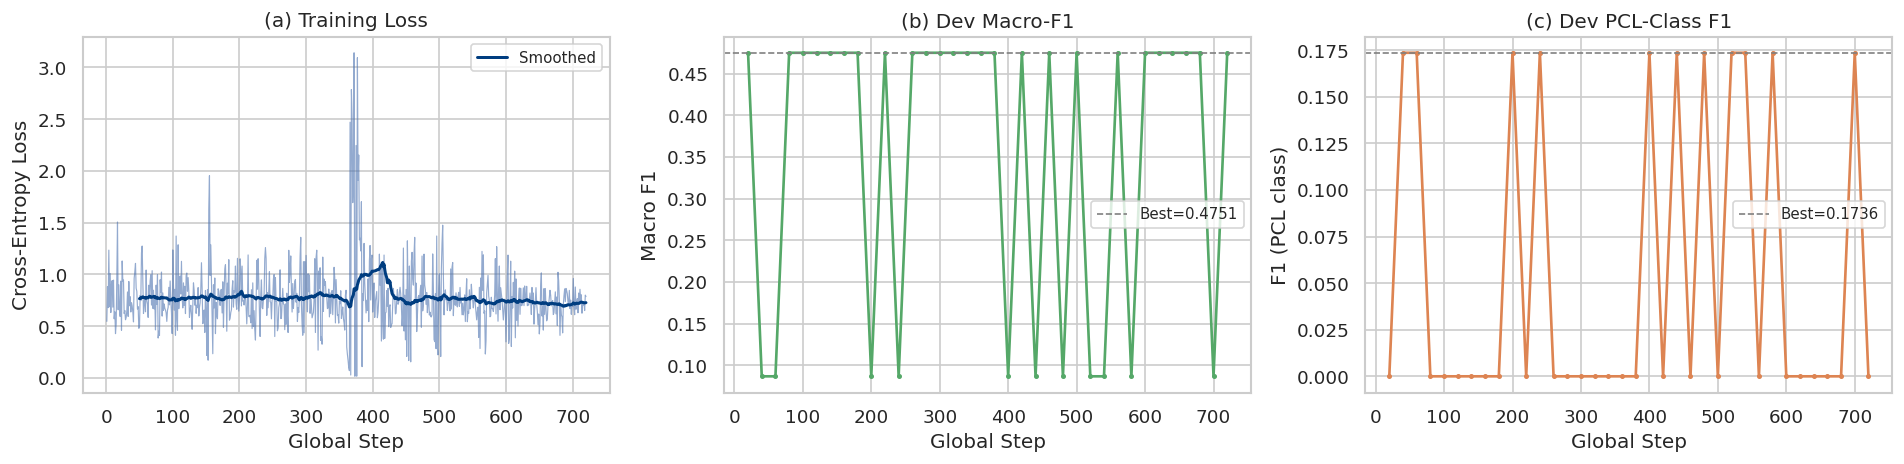

In [16]:
# ============================================================
# Cell 14: Training curves
# ============================================================

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Training loss
if history['train_loss']:
    steps, losses = zip(*history['train_loss'])
    axes[0].plot(steps, losses, linewidth=0.7, alpha=0.6, color='#4C72B0')
    # Smoothed
    window = min(50, len(losses))
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    axes[0].plot(steps[window-1:], smoothed, linewidth=1.8, color='#003d80', label='Smoothed')
    axes[0].set_title('(a) Training Loss')
    axes[0].set_xlabel('Global Step')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend(fontsize=9)

# (b) Dev macro-F1
if history['val_f1_macro']:
    steps, f1s = zip(*history['val_f1_macro'])
    axes[1].plot(steps, f1s, color='#55A868', linewidth=1.6, marker='o', markersize=2)
    axes[1].axhline(best_val_f1, linestyle='--', color='grey', linewidth=1, label=f'Best={best_val_f1:.4f}')
    axes[1].set_title('(b) Dev Macro-F1')
    axes[1].set_xlabel('Global Step')
    axes[1].set_ylabel('Macro F1')
    axes[1].legend(fontsize=9)

# (c) Dev PCL F1
if history['val_f1_pcl']:
    steps, f1s = zip(*history['val_f1_pcl'])
    axes[2].plot(steps, f1s, color='#DD8452', linewidth=1.6, marker='o', markersize=2)
    best_pcl = max(f1s)
    axes[2].axhline(best_pcl, linestyle='--', color='grey', linewidth=1, label=f'Best={best_pcl:.4f}')
    axes[2].set_title('(c) Dev PCL-Class F1')
    axes[2].set_xlabel('Global Step')
    axes[2].set_ylabel('F1 (PCL class)')
    axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, f'training_curves_{timestamp}.png'), bbox_inches='tight')
plt.show()

In [17]:
# ============================================================
# Cell 15: Load best checkpoint
# ============================================================

checkpoint = torch.load(BEST_CKPT_PATH, map_location=DEVICE)

# Re-instantiate model and load weights
best_model = DeBERTaClassifier().to(DEVICE)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

logger.info(
    f'Loaded best checkpoint from epoch {checkpoint["epoch"]}, '
    f'step {checkpoint["global_step"]}, '
    f'dev macro-F1={checkpoint["best_val_f1"]:.4f}'
)
print(f'Best checkpoint: epoch {checkpoint["epoch"]} | '
      f'step {checkpoint["global_step"]} | '
      f'val macro-F1={checkpoint["best_val_f1"]:.4f}')

11:50:04 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
11:50:04 | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json "HTTP/1.1 200 OK"
11:50:04 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
11:50:04 | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-base/8ccc9b6f36199bec6961081d44eb72fb3f7353f3/config.json "HTTP/1.1 200 OK"
11:50:04 | INFO     | HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
11:50:04 | INFO     | HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base "HTTP/1.1 200 OK"
11:50:04 | INFO     | HTTP Request: GET https://huggingface.co/api

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

11:50:04 | INFO     | HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-base/discussions?p=0 "HTTP/1.1 200 OK"
DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored whe

Best checkpoint: epoch 1 | step 20 | val macro-F1=0.4751


---
## Evaluation Harness

Evaluates the best checkpoint on the **held-out dev set** and reports:
- Per-class **F1**, **Precision** and **Recall** (both No-PCL and PCL classes)
- Full `sklearn` classification report
- Confusion matrix
- Bar chart comparison of metrics across classes

In [18]:
# ============================================================
# Cell 16: Run evaluation
# ============================================================

eval_metrics = evaluate(best_model, dev_loader)

print('=' * 60)
print('EVALUATION RESULTS — Dev Set')
print('=' * 60)

# Per-class table
results_table = pd.DataFrame({
    'Class'    : ['No PCL (0)', 'PCL (1)'],
    'Precision': [eval_metrics['prec_no_pcl'],  eval_metrics['prec_pcl']],
    'Recall'   : [eval_metrics['rec_no_pcl'],   eval_metrics['rec_pcl']],
    'F1'       : [eval_metrics['f1_no_pcl'],    eval_metrics['f1_pcl']],
})
results_table[['Precision', 'Recall', 'F1']] = results_table[['Precision', 'Recall', 'F1']].round(4)

print(f'\nMacro-F1 : {eval_metrics["f1_macro"]:.4f}')
print()
print(results_table.to_string(index=False))

print('\n--- Full Classification Report ---')
print(
    classification_report(
        eval_metrics['labels'],
        eval_metrics['preds'],
        target_names=['No PCL (0)', 'PCL (1)'],
        digits=4,
    )
)

logger.info(f'Dev macro-F1  : {eval_metrics["f1_macro"]:.4f}')
logger.info(f'Dev F1 (PCL)  : {eval_metrics["f1_pcl"]:.4f}')
logger.info(f'Dev Prec (PCL): {eval_metrics["prec_pcl"]:.4f}')
logger.info(f'Dev Rec  (PCL): {eval_metrics["rec_pcl"]:.4f}')

11:50:26 | INFO     | Dev macro-F1  : 0.4751
11:50:26 | INFO     | Dev F1 (PCL)  : 0.0000
11:50:26 | INFO     | Dev Prec (PCL): 0.0000
11:50:26 | INFO     | Dev Rec  (PCL): 0.0000


EVALUATION RESULTS — Dev Set

Macro-F1 : 0.4751

     Class  Precision  Recall     F1
No PCL (0)      0.905     1.0 0.9501
   PCL (1)      0.000     0.0 0.0000

--- Full Classification Report ---
              precision    recall  f1-score   support

  No PCL (0)     0.9050    1.0000    0.9501      1895
     PCL (1)     0.0000    0.0000    0.0000       199

    accuracy                         0.9050      2094
   macro avg     0.4525    0.5000    0.4751      2094
weighted avg     0.8190    0.9050    0.8598      2094



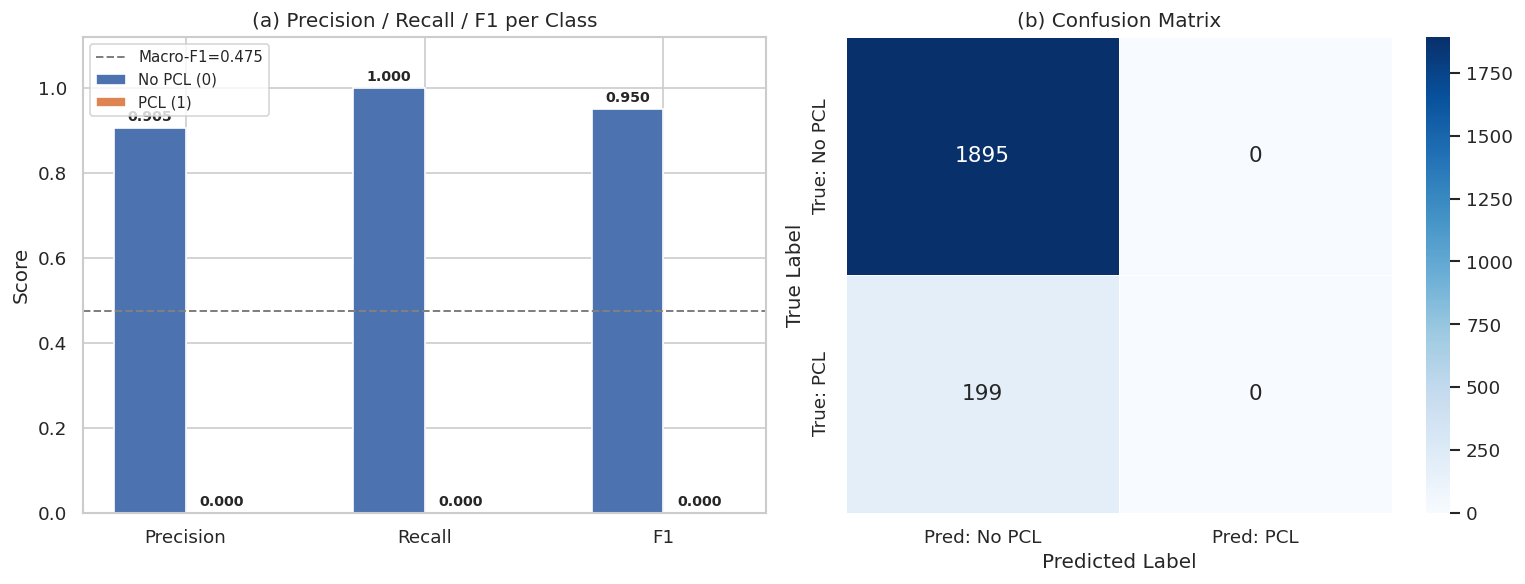

Evaluation plots saved to logs/


In [19]:
# ============================================================
# Cell 17: Evaluation plots
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_cls = ['#4C72B0', '#DD8452']

# ── (a) Per-class Precision / Recall / F1 ──────────────────
ax = axes[0]
metrics_names   = ['Precision', 'Recall', 'F1']
no_pcl_vals     = [eval_metrics['prec_no_pcl'], eval_metrics['rec_no_pcl'],  eval_metrics['f1_no_pcl']]
pcl_vals        = [eval_metrics['prec_pcl'],    eval_metrics['rec_pcl'],     eval_metrics['f1_pcl']]

x  = np.arange(len(metrics_names))
w  = 0.30
b1 = ax.bar(x - w/2, no_pcl_vals, width=w, color=colors_cls[0], label='No PCL (0)', edgecolor='white')
b2 = ax.bar(x + w/2, pcl_vals,    width=w, color=colors_cls[1], label='PCL (1)',    edgecolor='white')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 0.01,
        f'{h:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold',
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('(a) Precision / Recall / F1 per Class')
ax.legend()
ax.axhline(eval_metrics['f1_macro'], linestyle='--', color='grey',
           linewidth=1.2, label=f'Macro-F1={eval_metrics["f1_macro"]:.3f}')
ax.legend(fontsize=9)

# ── (b) Confusion matrix ───────────────────────────────────
ax   = axes[1]
cm   = confusion_matrix(eval_metrics['labels'], eval_metrics['preds'])
disp = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: No PCL', 'Pred: PCL'],
    yticklabels=['True: No PCL', 'True: PCL'],
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 13},
)
ax.set_title('(b) Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, f'eval_metrics_{timestamp}.png'), bbox_inches='tight')
plt.show()

print(f'Evaluation plots saved to logs/')